# Credit Risk Prediction — Loan Default Classification

**Goal:** Predict whether a loan applicant is likely to default, using applicant demographics and loan characteristics, to support lending decisions.

**Note on data:** This notebook currently runs on a synthetically generated dataset built to match the schema of the public Kaggle *Credit Risk Dataset* (same columns, realistic feature relationships, ~27% default rate). Swap in the real Kaggle CSV (same column names) to re-run this pipeline on real applicant data — the code doesn't change.

**Author:** Hrishikesh Mishra


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("data/credit_risk_dataset.csv")
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,58,43613,RENT,NaN,HOMEIMPROVEMENT,B,9633,8.80,0.221,N,29,0
1,48,93753,MORTGAGE,NaN,EDUCATION,D,23179,14.77,0.247,N,12,0
2,34,68064,RENT,1.8,VENTURE,B,10960,9.46,0.161,N,23,0
3,62,16106,MORTGAGE,0.7,EDUCATION,A,9549,7.40,0.593,N,27,0
4,27,54734,OWN,2.7,HOMEIMPROVEMENT,C,10278,13.53,0.188,N,17,1


## 1. Exploratory Data Analysis

In [2]:
print(df.shape)
df.info()


(8000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  8000 non-null   int64  
 1   person_income               8000 non-null   int64  
 2   person_home_ownership       8000 non-null   str    
 3   person_emp_length           7520 non-null   float64
 4   loan_intent                 8000 non-null   str    
 5   loan_grade                  8000 non-null   str    
 6   loan_amnt                   8000 non-null   int64  
 7   loan_int_rate               7200 non-null   float64
 8   loan_percent_income         8000 non-null   float64
 9   cb_person_default_on_file   8000 non-null   str    
 10  cb_person_cred_hist_length  8000 non-null   int64  
 11  loan_status                 8000 non-null   int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 750.1 KB


In [3]:
df.isna().sum()


person_age                      0
person_income                   0
person_home_ownership           0
person_emp_length             480
loan_intent                     0
loan_grade                      0
loan_amnt                       0
loan_int_rate                 800
loan_percent_income             0
cb_person_default_on_file       0
cb_person_cred_hist_length      0
loan_status                     0
dtype: int64

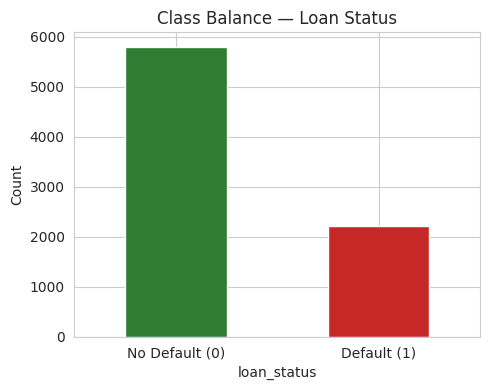

In [4]:
fig, ax = plt.subplots(figsize=(5,4))
df["loan_status"].value_counts().plot(kind="bar", ax=ax, color=["#2E7D32", "#C62828"])
ax.set_xticklabels(["No Default (0)", "Default (1)"], rotation=0)
ax.set_title("Class Balance — Loan Status")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("images/class_balance.png")
plt.show()


**Observation:** ~27.5% of applicants defaulted. This is imbalanced enough that plain accuracy would be misleading — a model that always predicts "no default" would still score ~72% accuracy while being useless. Precision, recall, and ROC-AUC matter more here than accuracy.

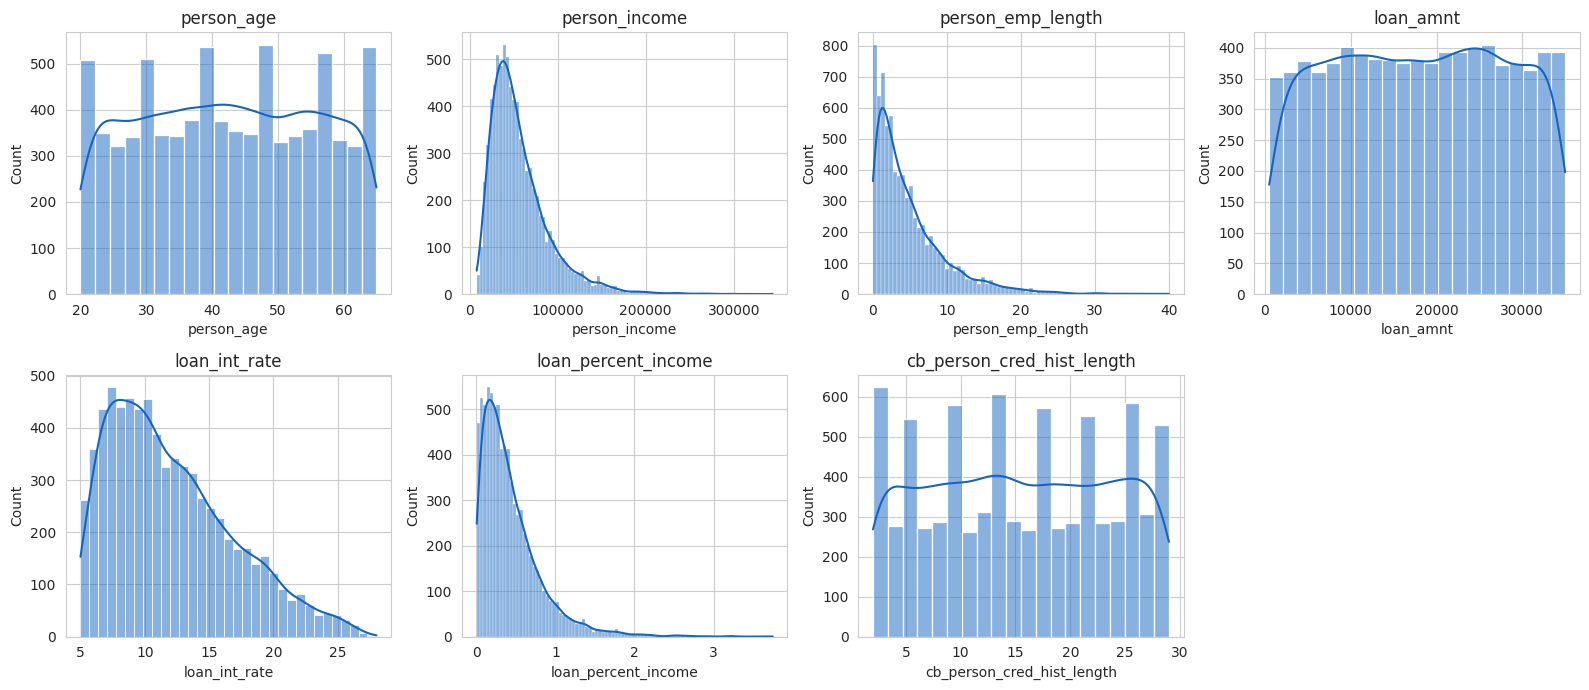

In [5]:
numeric_cols = ["person_age", "person_income", "person_emp_length", "loan_amnt",
                 "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#1565C0")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("images/distributions.png")
plt.show()


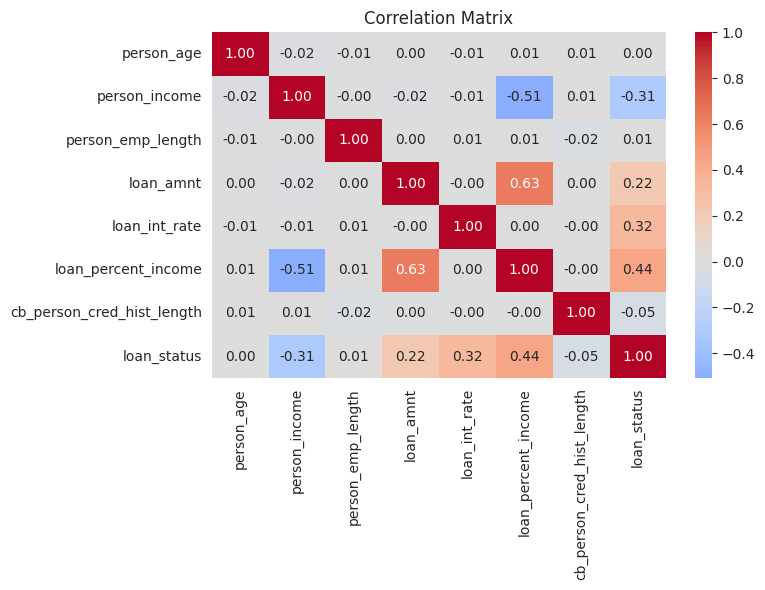

In [6]:
fig, ax = plt.subplots(figsize=(8,6))
corr = df[numeric_cols + ["loan_status"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.savefig("images/correlation.png")
plt.show()


**Observation:** `loan_percent_income` and `loan_int_rate` show the strongest positive correlation with default, while `cb_person_cred_hist_length` and `person_income` are mildly protective. This lines up with lending intuition — the fraction of income a loan consumes, and the rate a lender charges (which itself reflects perceived risk), are leading indicators of default.

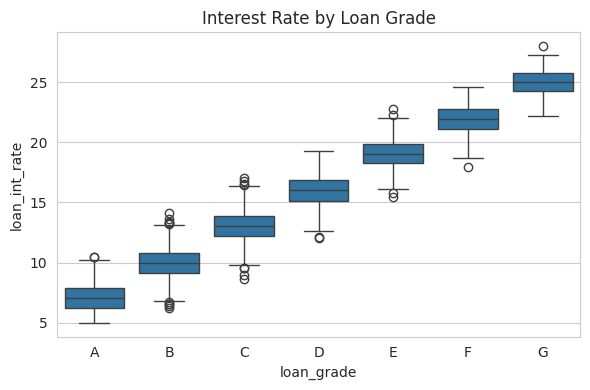

In [7]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x="loan_grade", y="loan_int_rate", order=list("ABCDEFG"), ax=ax)
ax.set_title("Interest Rate by Loan Grade")
plt.tight_layout()
plt.savefig("images/grade_vs_rate.png")
plt.show()


## 2. Data Cleaning & Feature Engineering

In [8]:
df_clean = df.copy()

# Impute missing employment length with median (robust to outliers)
df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(
    df_clean["person_emp_length"].median()
)

# Impute missing interest rate with the median rate for that loan grade
df_clean["loan_int_rate"] = df_clean.groupby("loan_grade")["loan_int_rate"].transform(
    lambda x: x.fillna(x.median())
)

assert df_clean.isna().sum().sum() == 0
print("Missing values remaining:", df_clean.isna().sum().sum())


Missing values remaining: 0


In [9]:
# Feature engineering: debt servicing burden relative to credit history
df_clean["income_per_credit_year"] = (
    df_clean["person_income"] / (df_clean["cb_person_cred_hist_length"] + 1)
)
df_clean["loan_to_emp_length"] = (
    df_clean["loan_amnt"] / (df_clean["person_emp_length"] + 1)
)

categorical_cols = ["person_home_ownership", "loan_intent", "loan_grade",
                     "cb_person_default_on_file"]

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
df_encoded.shape


(8000, 25)

## 3. Train / Test Split & Scaling

In [10]:
X = df_encoded.drop(columns=["loan_status"])
y = df_encoded["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train default rate: %.3f | Test default rate: %.3f" %
      (y_train.mean(), y_test.mean()))


Train shape: (6400, 24) | Test shape: (1600, 24)
Train default rate: 0.275 | Test default rate: 0.276


## 4. Model Training — Logistic Regression, Random Forest, SVM, Voting Ensemble

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8,
                                             class_weight="balanced", random_state=42),
    "SVM (RBF)": SVC(probability=True, class_weight="balanced", random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        "model": model,
        "preds": preds,
        "proba": proba,
        "roc_auc": roc_auc_score(y_test, proba),
    }
    print(f"--- {name} ---")
    print(classification_report(y_test, preds, target_names=["No Default", "Default"]))
    print(f"ROC-AUC: {results[name]['roc_auc']:.4f}\n")


--- Logistic Regression ---
              precision    recall  f1-score   support

  No Default       0.90      0.80      0.85      1159
     Default       0.59      0.76      0.66       441

    accuracy                           0.79      1600
   macro avg       0.74      0.78      0.75      1600
weighted avg       0.81      0.79      0.80      1600

ROC-AUC: 0.8609



--- Random Forest ---
              precision    recall  f1-score   support

  No Default       0.89      0.83      0.86      1159
     Default       0.61      0.73      0.67       441

    accuracy                           0.80      1600
   macro avg       0.75      0.78      0.76      1600
weighted avg       0.81      0.80      0.80      1600

ROC-AUC: 0.8469



--- SVM (RBF) ---
              precision    recall  f1-score   support

  No Default       0.90      0.80      0.85      1159
     Default       0.59      0.76      0.66       441

    accuracy                           0.79      1600
   macro avg       0.74      0.78      0.75      1600
weighted avg       0.81      0.79      0.80      1600

ROC-AUC: 0.8401



In [12]:
voting_clf = VotingClassifier(
    estimators=[
        ("lr", models["Logistic Regression"]),
        ("rf", models["Random Forest"]),
        ("svm", models["SVM (RBF)"]),
    ],
    voting="soft",
)
voting_clf.fit(X_train_scaled, y_train)
voting_preds = voting_clf.predict(X_test_scaled)
voting_proba = voting_clf.predict_proba(X_test_scaled)[:, 1]

print("--- Voting Classifier (Ensemble) ---")
print(classification_report(y_test, voting_preds, target_names=["No Default", "Default"]))
voting_auc = roc_auc_score(y_test, voting_proba)
print(f"ROC-AUC: {voting_auc:.4f}")

results["Voting Ensemble"] = {"preds": voting_preds, "proba": voting_proba, "roc_auc": voting_auc}


--- Voting Classifier (Ensemble) ---
              precision    recall  f1-score   support

  No Default       0.88      0.85      0.86      1159
     Default       0.64      0.70      0.67       441

    accuracy                           0.81      1600
   macro avg       0.76      0.77      0.77      1600
weighted avg       0.81      0.81      0.81      1600

ROC-AUC: 0.8560


## 5. Evaluation — Confusion Matrix & ROC Curve

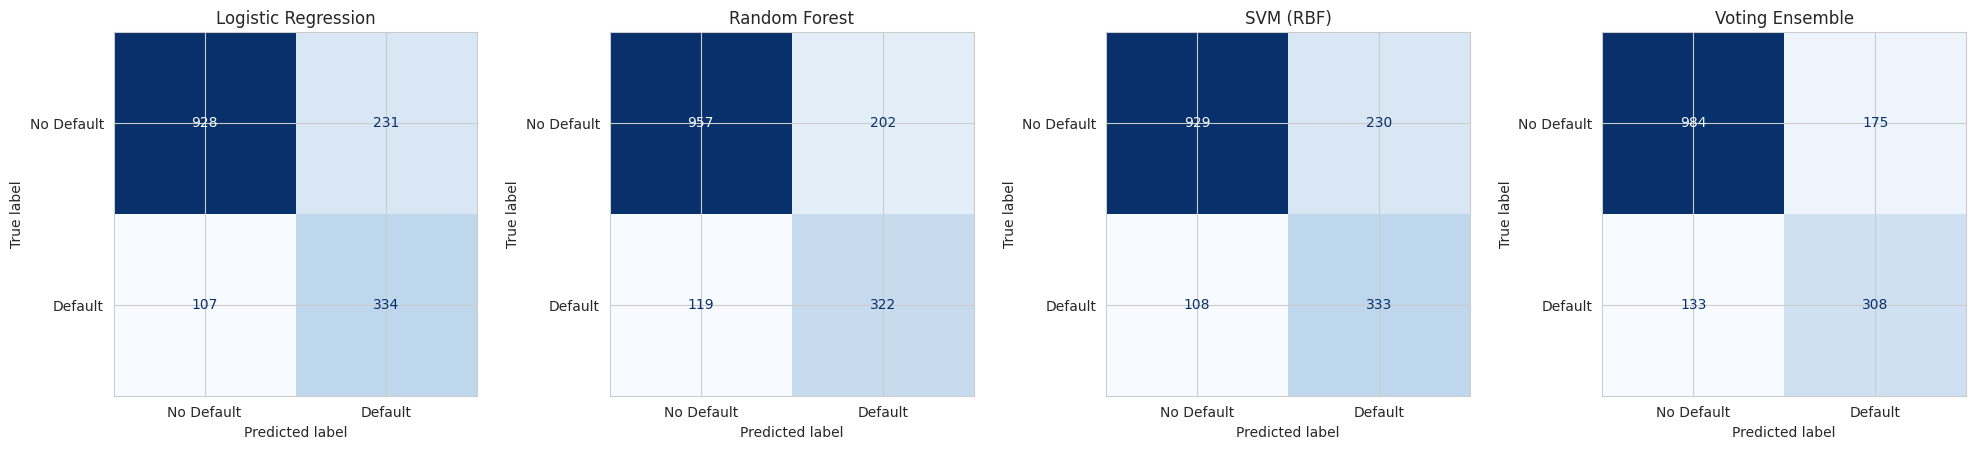

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, name in zip(axes, results.keys()):
    cm = confusion_matrix(y_test, results[name]["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.savefig("images/confusion_matrices.png")
plt.show()


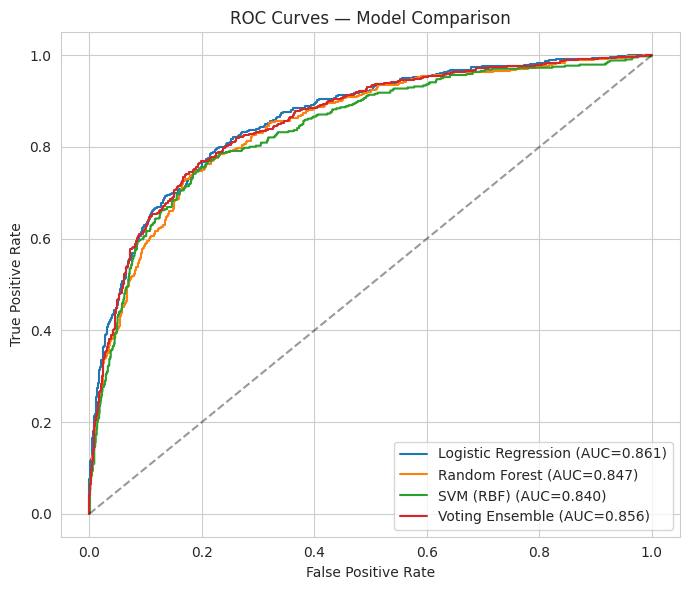

In [14]:
fig, ax = plt.subplots(figsize=(7,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")
ax.plot([0,1],[0,1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Model Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("images/roc_curves.png")
plt.show()


In [15]:
summary = pd.DataFrame({
    "Model": list(results.keys()),
    "ROC-AUC": [round(results[n]["roc_auc"], 4) for n in results],
})
summary = summary.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
summary


,Model,ROC-AUC
0,Logistic Regression,0.8609
1,Voting Ensemble,0.8560
2,Random Forest,0.8469
3,SVM (RBF),0.8401


## 6. Feature Importance (Random Forest)

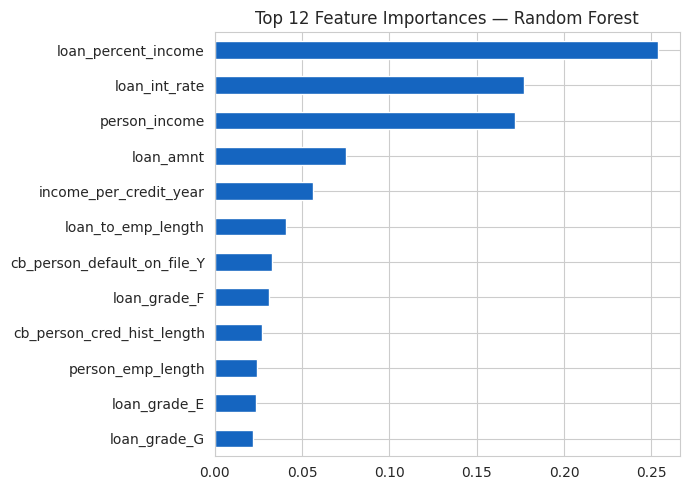

In [16]:
importances = pd.Series(
    models["Random Forest"].feature_importances_, index=X.columns
).sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7,5))
importances.plot(kind="barh", ax=ax, color="#1565C0")
ax.invert_yaxis()
ax.set_title("Top 12 Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("images/feature_importance.png")
plt.show()


## 7. Key Insights (business-readable summary)

1. **Loan-to-income ratio and interest rate are the strongest default predictors** — applicants borrowing a larger share of their income, or already priced at a higher rate (signaling the lender's own risk assessment), are meaningfully more likely to default.
2. **Credit history length is protective** — longer credit history correlates with lower default risk, consistent with standard underwriting practice.
3. **Class imbalance (~27.5% default rate) means recall on the "Default" class matters more than raw accuracy** — for a lender, missing an actual defaulter (false negative) is more costly than being overly cautious with a safe applicant (false positive). Models here were trained with `class_weight="balanced"` for this reason.
4. **The Voting Ensemble combines the strengths of Logistic Regression (interpretable, stable), Random Forest (captures non-linear interactions), and SVM (strong margin-based separation)** — matching the ensemble approach used in my earlier Disease Prediction System project, applied here to a financial risk context instead of a healthcare one.

### Next steps if extended
- Threshold tuning based on a bank's actual cost-of-false-negative vs cost-of-false-positive ratio
- SHAP values for per-applicant explainability (important for regulated lending decisions)
- Re-run on the real Kaggle Credit Risk Dataset once downloaded, to validate these findings on real applicant data
